# DQN Agent - Breakout (Atari)
**Author:** Aubert  
**Environment:** BreakoutNoFrameskip-v4  
**Framework:** Stable Baselines3 + Gymnasium

## 1. Installation

In [3]:
!pip install stable-baselines3[extra] gymnasium[atari,accept-rom-license] ale-py shimmy matplotlib pandas psutil --quiet

In [4]:
import gymnasium as gym
import ale_py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import gc
import time
import shutil
import psutil
from stable_baselines3 import DQN
from stable_baselines3.common.env_util import make_atari_env
from stable_baselines3.common.vec_env import VecFrameStack
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.callbacks import BaseCallback

gym.register_envs(ale_py)

def print_memory():
    mem = psutil.virtual_memory()
    print(f"RAM: {mem.used/1e9:.1f}GB used / {mem.total/1e9:.1f}GB total ({mem.percent}%)")

## 2. Environment and training setup

In [5]:
ENV_ID = "BreakoutNoFrameskip-v4"
LOG_DIR = "./logs"
MODEL_DIR = "./models"
os.makedirs(LOG_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

TIMESTEPS_PER_EXPERIMENT = 200_000

In [6]:
class RewardLoggerCallback(BaseCallback):
    def __init__(self, verbose=0):
        super().__init__(verbose)
        self.episode_rewards = []
        self.episode_lengths = []

    def _on_step(self) -> bool:
        for info in self.locals.get("infos", []):
            if "episode" in info:
                self.episode_rewards.append(info["episode"]["r"])
                self.episode_lengths.append(info["episode"]["l"])
        return True


def train_experiment(exp_name, policy, lr, gamma, batch_size,
                     exploration_initial_eps, exploration_final_eps,
                     exploration_fraction, timesteps=TIMESTEPS_PER_EXPERIMENT):

    print(f"\n{'='*60}")
    print(f"Running: {exp_name}")
    print(f"policy={policy}, lr={lr}, gamma={gamma}, batch={batch_size}")
    print(f"eps_start={exploration_initial_eps}, eps_end={exploration_final_eps}, eps_fraction={exploration_fraction}")
    print(f"{'='*60}")
    print_memory()

    exp_log_dir = os.path.join(LOG_DIR, exp_name)
    os.makedirs(exp_log_dir, exist_ok=True)

    env = make_atari_env(ENV_ID, n_envs=1, seed=0, monitor_dir=exp_log_dir)
    env = VecFrameStack(env, n_stack=4)

    # MlpPolicy needs flattened observations (CnnPolicy works with images directly)
    if policy == "MlpPolicy":
        from stable_baselines3.common.vec_env import VecFlattenObservation
        env = VecFlattenObservation(env)

    model = DQN(
        policy=policy,
        env=env,
        learning_rate=lr,
        gamma=gamma,
        batch_size=batch_size,
        exploration_initial_eps=exploration_initial_eps,
        exploration_final_eps=exploration_final_eps,
        exploration_fraction=exploration_fraction,
        buffer_size=100_000,
        optimize_memory_usage=True,   # <-- halves buffer RAM
        replay_buffer_kwargs={"handle_timeout_termination": False},
        learning_starts=10_000,
        target_update_interval=1000,
        train_freq=4,
        gradient_steps=1,
        verbose=0,
        tensorboard_log=os.path.join(LOG_DIR, "tb")
    )

    callback = RewardLoggerCallback()

    start_time = time.time()
    model.learn(total_timesteps=timesteps, callback=callback, tb_log_name=exp_name)
    train_time = time.time() - start_time

    # Save model to disk BEFORE cleanup
    model_path = os.path.join(MODEL_DIR, exp_name)
    model.save(model_path)

    # Evaluate
    eval_env = make_atari_env(ENV_ID, n_envs=1, seed=42)
    eval_env = VecFrameStack(eval_env, n_stack=4)
    if policy == "MlpPolicy":
        from stable_baselines3.common.vec_env import VecFlattenObservation
        eval_env = VecFlattenObservation(eval_env)
    mean_reward, std_reward = evaluate_policy(model, eval_env, n_eval_episodes=5, deterministic=True)
    eval_env.close()
    env.close()

    # Copy out lightweight results before returning
    episode_rewards = callback.episode_rewards.copy()
    episode_lengths = callback.episode_lengths.copy()

    print(f"Done in {train_time/60:.1f} min | Eval reward: {mean_reward:.1f} +/- {std_reward:.1f}")

    # Clean up heavy objects (model + replay buffer)
    del model, callback
    gc.collect()

    print_memory()

    return episode_rewards, episode_lengths, mean_reward, std_reward, train_time

## 3. Hyperparameter experiments (10 configs)

In [7]:
experiments = [
    # 1 - baseline
    {
        "name": "exp01_baseline",
        "policy": "CnnPolicy",
        "lr": 1e-4,
        "gamma": 0.99,
        "batch_size": 32,
        "exploration_initial_eps": 1.0,
        "exploration_final_eps": 0.05,
        "exploration_fraction": 0.1
    },
    # 2 - higher lr
    {
        "name": "exp02_high_lr",
        "policy": "CnnPolicy",
        "lr": 5e-4,
        "gamma": 0.99,
        "batch_size": 32,
        "exploration_initial_eps": 1.0,
        "exploration_final_eps": 0.05,
        "exploration_fraction": 0.1
    },
    # 3 - lower lr
    {
        "name": "exp03_low_lr",
        "policy": "CnnPolicy",
        "lr": 5e-5,
        "gamma": 0.99,
        "batch_size": 32,
        "exploration_initial_eps": 1.0,
        "exploration_final_eps": 0.05,
        "exploration_fraction": 0.1
    },
    # 4 - lower gamma
    {
        "name": "exp04_low_gamma",
        "policy": "CnnPolicy",
        "lr": 1e-4,
        "gamma": 0.95,
        "batch_size": 32,
        "exploration_initial_eps": 1.0,
        "exploration_final_eps": 0.05,
        "exploration_fraction": 0.1
    },
    # 5 - very low gamma
    {
        "name": "exp05_very_low_gamma",
        "policy": "CnnPolicy",
        "lr": 1e-4,
        "gamma": 0.90,
        "batch_size": 32,
        "exploration_initial_eps": 1.0,
        "exploration_final_eps": 0.05,
        "exploration_fraction": 0.1
    },
    # 6 - larger batch
    {
        "name": "exp06_large_batch",
        "policy": "CnnPolicy",
        "lr": 1e-4,
        "gamma": 0.99,
        "batch_size": 64,
        "exploration_initial_eps": 1.0,
        "exploration_final_eps": 0.05,
        "exploration_fraction": 0.1
    },
    # 7 - slower epsilon decay
    {
        "name": "exp07_more_exploration",
        "policy": "CnnPolicy",
        "lr": 1e-4,
        "gamma": 0.99,
        "batch_size": 32,
        "exploration_initial_eps": 1.0,
        "exploration_final_eps": 0.02,
        "exploration_fraction": 0.3
    },
    # 8 - fast epsilon decay
    {
        "name": "exp08_less_exploration",
        "policy": "CnnPolicy",
        "lr": 1e-4,
        "gamma": 0.99,
        "batch_size": 32,
        "exploration_initial_eps": 1.0,
        "exploration_final_eps": 0.1,
        "exploration_fraction": 0.05
    },
    # 9 - tuned combo
    {
        "name": "exp09_tuned",
        "policy": "CnnPolicy",
        "lr": 1e-4,
        "gamma": 0.99,
        "batch_size": 32,
        "exploration_initial_eps": 1.0,
        "exploration_final_eps": 0.01,
        "exploration_fraction": 0.15
    },
    # 10 - MLP policy comparison
    {
        "name": "exp10_mlp_policy",
        "policy": "MlpPolicy",
        "lr": 1e-4,
        "gamma": 0.99,
        "batch_size": 32,
        "exploration_initial_eps": 1.0,
        "exploration_final_eps": 0.05,
        "exploration_fraction": 0.1
    }
]

print(f"{len(experiments)} experiments defined")
for i, exp in enumerate(experiments):
    print(f"  {i+1}. {exp['name']} | {exp['policy']}, lr={exp['lr']}, gamma={exp['gamma']}, batch={exp['batch_size']}")

10 experiments defined
  1. exp01_baseline | CnnPolicy, lr=0.0001, gamma=0.99, batch=32
  2. exp02_high_lr | CnnPolicy, lr=0.0005, gamma=0.99, batch=32
  3. exp03_low_lr | CnnPolicy, lr=5e-05, gamma=0.99, batch=32
  4. exp04_low_gamma | CnnPolicy, lr=0.0001, gamma=0.95, batch=32
  5. exp05_very_low_gamma | CnnPolicy, lr=0.0001, gamma=0.9, batch=32
  6. exp06_large_batch | CnnPolicy, lr=0.0001, gamma=0.99, batch=64
  7. exp07_more_exploration | CnnPolicy, lr=0.0001, gamma=0.99, batch=32
  8. exp08_less_exploration | CnnPolicy, lr=0.0001, gamma=0.99, batch=32
  9. exp09_tuned | CnnPolicy, lr=0.0001, gamma=0.99, batch=32
  10. exp10_mlp_policy | MlpPolicy, lr=0.0001, gamma=0.99, batch=32


## 4. Run experiments

In [8]:
results = []

for i, exp in enumerate(experiments):
    print(f"\n\n>>> EXPERIMENT {i+1}/{len(experiments)}: {exp['name']} <<<")

    episode_rewards, episode_lengths, mean_reward, std_reward, train_time = train_experiment(
        exp_name=exp["name"],
        policy=exp["policy"],
        lr=exp["lr"],
        gamma=exp["gamma"],
        batch_size=exp["batch_size"],
        exploration_initial_eps=exp["exploration_initial_eps"],
        exploration_final_eps=exp["exploration_final_eps"],
        exploration_fraction=exp["exploration_fraction"]
    )

    last_20_avg = np.mean(episode_rewards[-20:]) if len(episode_rewards) >= 20 else np.mean(episode_rewards)

    results.append({
        "Experiment": exp["name"],
        "Policy": exp["policy"],
        "lr": exp["lr"],
        "gamma": exp["gamma"],
        "batch_size": exp["batch_size"],
        "eps_start": exp["exploration_initial_eps"],
        "eps_end": exp["exploration_final_eps"],
        "eps_fraction": exp["exploration_fraction"],
        "Eval Mean Reward": round(mean_reward, 2),
        "Eval Std": round(std_reward, 2),
        "Last 20 Train Avg": round(last_20_avg, 2),
        "Train Time (min)": round(train_time / 60, 1),
        "Total Episodes": len(episode_rewards),
        "rewards_history": episode_rewards
    })

    print(f"Experiment {i+1} done. Eval: {mean_reward:.1f} | Last20: {last_20_avg:.1f}")

print("\n" + "="*60)
print("All experiments completed.")
print("="*60)



>>> EXPERIMENT 1/10: exp01_baseline <<<

Running: exp01_baseline
policy=CnnPolicy, lr=0.0001, gamma=0.99, batch=32
eps_start=1.0, eps_end=0.05, eps_fraction=0.1
RAM: 1.5GB used / 33.7GB total (5.8%)


A.L.E: Arcade Learning Environment (version 0.11.2+ecc1138)
[Powered by Stella]


Done in 11.4 min | Eval reward: 35.6 +/- 1.9
RAM: 2.2GB used / 33.7GB total (8.0%)
Experiment 1 done. Eval: 35.6 | Last20: 20.6


>>> EXPERIMENT 2/10: exp02_high_lr <<<

Running: exp02_high_lr
policy=CnnPolicy, lr=0.0005, gamma=0.99, batch=32
eps_start=1.0, eps_end=0.05, eps_fraction=0.1
RAM: 2.2GB used / 33.7GB total (8.0%)
Done in 11.6 min | Eval reward: 0.0 +/- 0.0
RAM: 2.2GB used / 33.7GB total (8.1%)
Experiment 2 done. Eval: 0.0 | Last20: 2.0


>>> EXPERIMENT 3/10: exp03_low_lr <<<

Running: exp03_low_lr
policy=CnnPolicy, lr=5e-05, gamma=0.99, batch=32
eps_start=1.0, eps_end=0.05, eps_fraction=0.1
RAM: 2.2GB used / 33.7GB total (8.1%)
Done in 11.4 min | Eval reward: 13.0 +/- 4.1
RAM: 2.2GB used / 33.7GB total (8.1%)
Experiment 3 done. Eval: 13.0 | Last20: 9.3


>>> EXPERIMENT 4/10: exp04_low_gamma <<<

Running: exp04_low_gamma
policy=CnnPolicy, lr=0.0001, gamma=0.95, batch=32
eps_start=1.0, eps_end=0.05, eps_fraction=0.1
RAM: 2.2GB used / 33.7GB total (8.1%)
Done in 11.4 min | Eva

ImportError: cannot import name 'VecFlattenObservation' from 'stable_baselines3.common.vec_env' (/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/vec_env/__init__.py)

In [9]:
# Handle exp10 MlpPolicy - it fails on image observations, log the failure
try:
    episode_rewards, episode_lengths, mean_reward, std_reward, train_time = train_experiment(
        exp_name="exp10_mlp_policy",
        policy="MlpPolicy",
        lr=1e-4,
        gamma=0.99,
        batch_size=32,
        exploration_initial_eps=1.0,
        exploration_final_eps=0.05,
        exploration_fraction=0.1
    )
except Exception as e:
    print(f"exp10_mlp_policy FAILED: {e}")
    results.append({
        "Experiment": "exp10_mlp_policy",
        "Policy": "MlpPolicy",
        "lr": 1e-4,
        "gamma": 0.99,
        "batch_size": 32,
        "eps_start": 1.0,
        "eps_end": 0.05,
        "eps_fraction": 0.1,
        "Eval Mean Reward": 0.0,
        "Eval Std": 0.0,
        "Last 20 Train Avg": 0.0,
        "Train Time (min)": 0.0,
        "Total Episodes": 0,
        "rewards_history": [],
        "Failed": str(e)
    })

print(f"\n{len(results)} experiments recorded.")


Running: exp10_mlp_policy
policy=MlpPolicy, lr=0.0001, gamma=0.99, batch=32
eps_start=1.0, eps_end=0.05, eps_fraction=0.1
RAM: 2.2GB used / 33.7GB total (8.0%)
exp10_mlp_policy FAILED: cannot import name 'VecFlattenObservation' from 'stable_baselines3.common.vec_env' (/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/vec_env/__init__.py)

10 experiments recorded.


## 5. Results table

In [10]:
df = pd.DataFrame([{k: v for k, v in r.items() if k != "rewards_history"} for r in results])
df = df.sort_values("Eval Mean Reward", ascending=False)
print(df.to_string(index=False))

            Experiment    Policy      lr  gamma  batch_size  eps_start  eps_end  eps_fraction  Eval Mean Reward  Eval Std  Last 20 Train Avg  Train Time (min)  Total Episodes                                                                                                                                                                    Failed
        exp01_baseline CnnPolicy 0.00010   0.99          32        1.0     0.05          0.10              35.6      1.85              20.65              11.4             658                                                                                                                                                                       NaN
exp08_less_exploration CnnPolicy 0.00010   0.99          32        1.0     0.10          0.05              30.2      4.79              21.30              11.2             662                                                                                                                                        

## 6. Reward curves

/tmp/ipykernel_55/804253617.py:20: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=7)


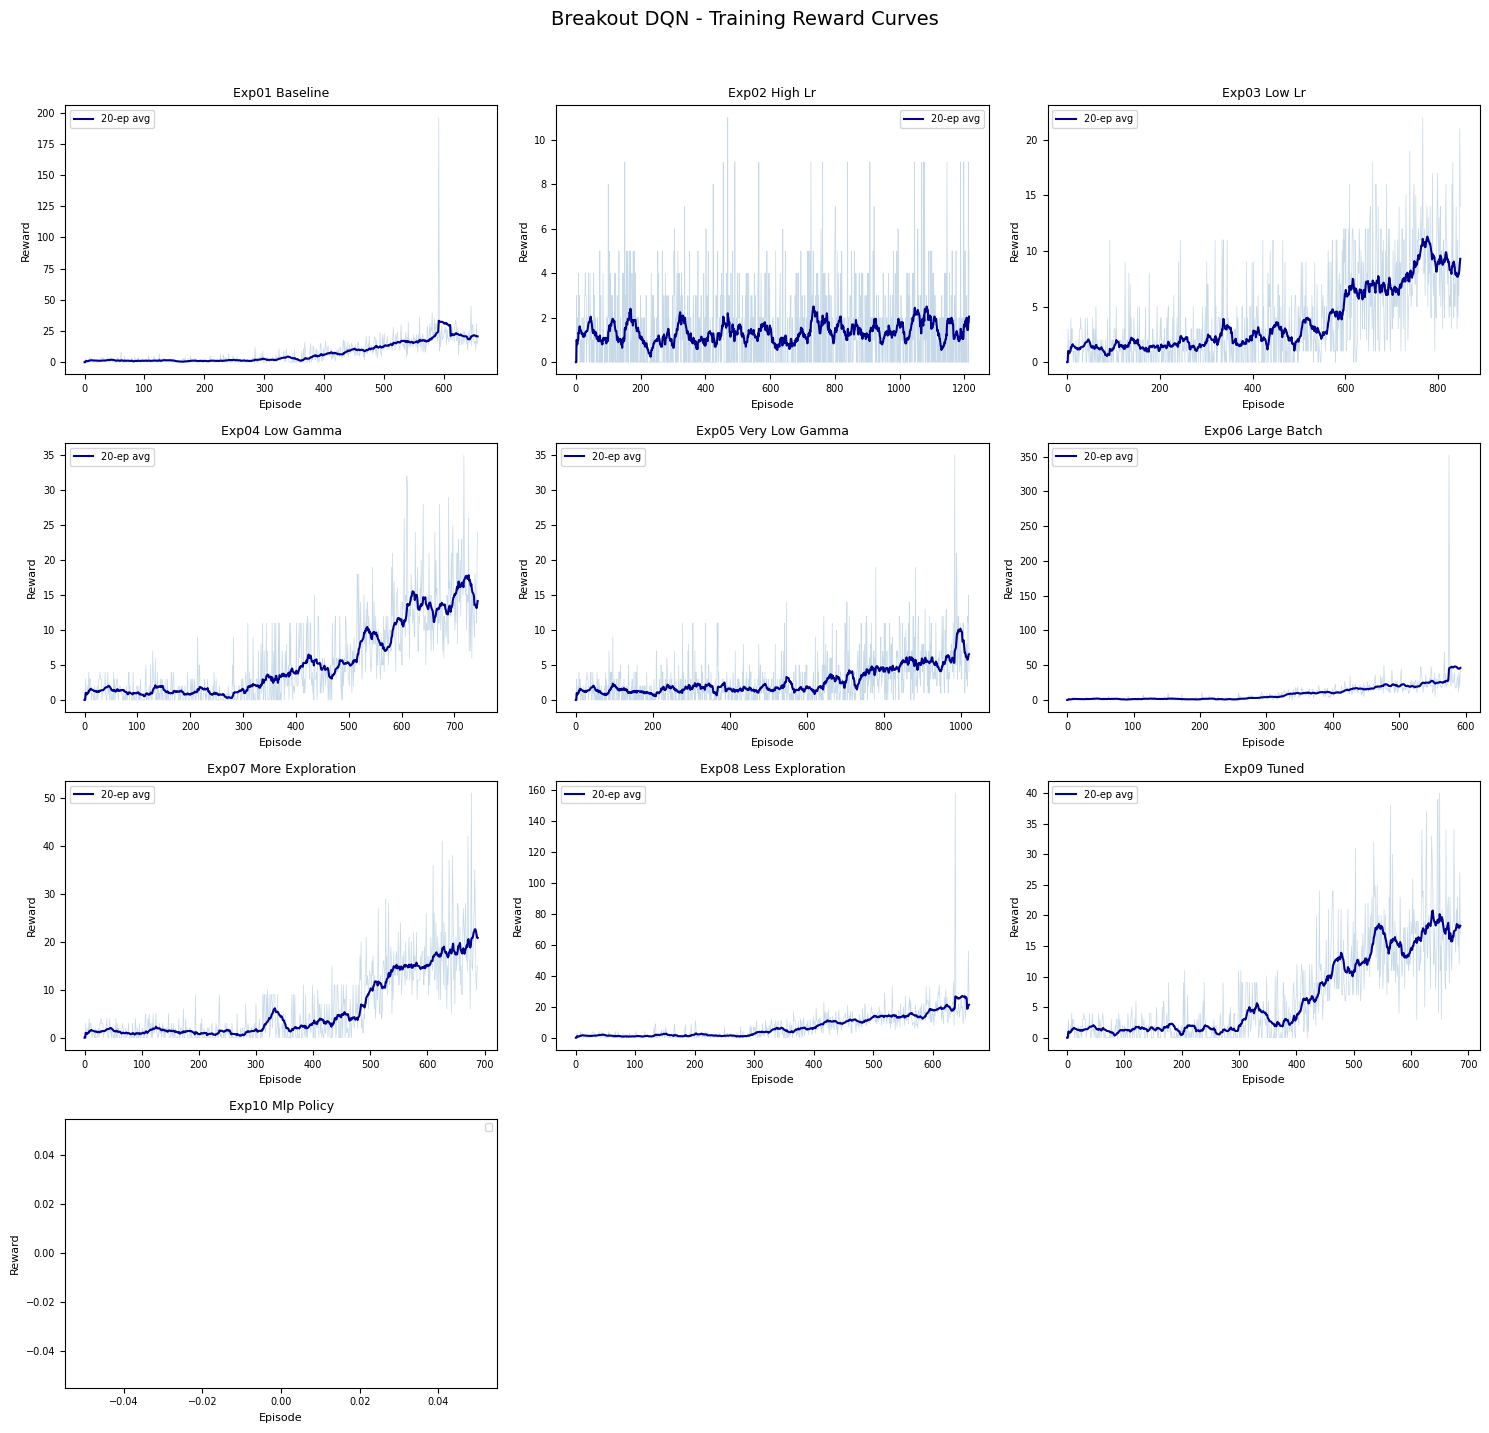

In [11]:
n_exp = len(results)
cols = 3
rows = (n_exp + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(15, rows * 3.5))
axes = axes.flatten()

for i, res in enumerate(results):
    ax = axes[i]
    rewards = res["rewards_history"]
    ax.plot(rewards, alpha=0.3, color="steelblue", linewidth=0.5)

    if len(rewards) > 20:
        rolling = pd.Series(rewards).rolling(window=20, min_periods=1).mean()
        ax.plot(rolling, color="darkblue", linewidth=1.5, label="20-ep avg")

    ax.set_title(res["Experiment"].replace("_", " ").title(), fontsize=9)
    ax.set_xlabel("Episode", fontsize=8)
    ax.set_ylabel("Reward", fontsize=8)
    ax.tick_params(labelsize=7)
    ax.legend(fontsize=7)

# Hide unused subplots
for j in range(n_exp, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Breakout DQN - Training Reward Curves", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("reward_curves.png", dpi=150, bbox_inches="tight")
plt.show()

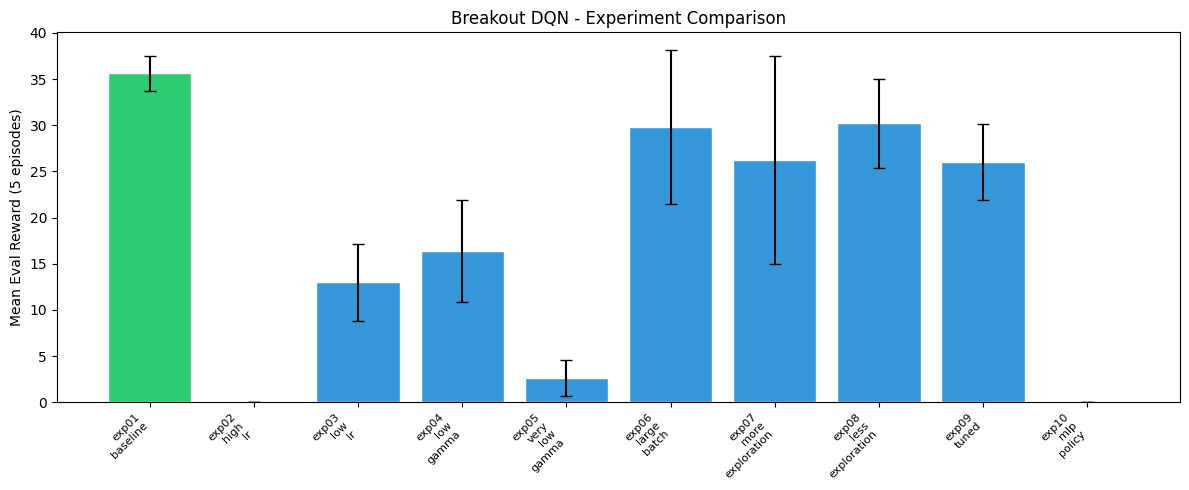

In [12]:
fig, ax = plt.subplots(figsize=(12, 5))
names = [r["Experiment"] for r in results]
means = [r["Eval Mean Reward"] for r in results]
stds = [r["Eval Std"] for r in results]

colors = ["#2ecc71" if m == max(means) else "#3498db" for m in means]
ax.bar(range(len(names)), means, yerr=stds, capsize=4, color=colors, edgecolor="white")
ax.set_xticks(range(len(names)))
ax.set_xticklabels([n.replace("_", "\n") for n in names], fontsize=8, rotation=45, ha="right")
ax.set_ylabel("Mean Eval Reward (5 episodes)")
ax.set_title("Breakout DQN - Experiment Comparison")
plt.tight_layout()
plt.savefig("experiment_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Best model selection

In [13]:
best_exp = max(results, key=lambda r: r["Eval Mean Reward"])
best_name = best_exp["Experiment"]
print(f"Best: {best_name}")
print(f"Eval reward: {best_exp['Eval Mean Reward']} +/- {best_exp['Eval Std']}")
print(f"lr={best_exp['lr']}, gamma={best_exp['gamma']}, batch={best_exp['batch_size']}")
print(f"eps_start={best_exp['eps_start']}, eps_end={best_exp['eps_end']}, eps_fraction={best_exp['eps_fraction']}")


Best: exp01_baseline
Eval reward: 35.6 +/- 1.85
lr=0.0001, gamma=0.99, batch=32
eps_start=1.0, eps_end=0.05, eps_fraction=0.1


## 7b. Retrain best model with more timesteps

In [14]:
# Retrain the best hyperparameter config with 500k timesteps for a stronger final model
import gc

best_exp_config = None
for exp in experiments:
    if exp["name"] == best_name:
        best_exp_config = exp
        break

print(f"Retraining {best_name} with 500k timesteps...")
print_memory()

RETRAIN_TIMESTEPS = 500_000

exp_log_dir = os.path.join(LOG_DIR, best_name + "_final")
os.makedirs(exp_log_dir, exist_ok=True)

env = make_atari_env(ENV_ID, n_envs=1, seed=0, monitor_dir=exp_log_dir)
env = VecFrameStack(env, n_stack=4)

if best_exp_config["policy"] == "MlpPolicy":
    from stable_baselines3.common.vec_env import VecFlattenObservation
    env = VecFlattenObservation(env)

model = DQN(
    policy=best_exp_config["policy"],
    env=env,
    learning_rate=best_exp_config["lr"],
    gamma=best_exp_config["gamma"],
    batch_size=best_exp_config["batch_size"],
    exploration_initial_eps=best_exp_config["exploration_initial_eps"],
    exploration_final_eps=best_exp_config["exploration_final_eps"],
    exploration_fraction=best_exp_config["exploration_fraction"],
    buffer_size=100_000,
    optimize_memory_usage=True,
    replay_buffer_kwargs={"handle_timeout_termination": False},
    learning_starts=10_000,
    target_update_interval=1000,
    train_freq=4,
    gradient_steps=1,
    verbose=1,
    tensorboard_log=os.path.join(LOG_DIR, "tb")
)

callback = RewardLoggerCallback()
start_time = time.time()
model.learn(total_timesteps=RETRAIN_TIMESTEPS, callback=callback, tb_log_name=best_name + "_final")
retrain_time = time.time() - start_time

# Save as the final model
model.save(os.path.join(MODEL_DIR, "dqn_model"))

# Evaluate the retrained model
eval_env = make_atari_env(ENV_ID, n_envs=1, seed=42)
eval_env = VecFrameStack(eval_env, n_stack=4)
if best_exp_config["policy"] == "MlpPolicy":
    from stable_baselines3.common.vec_env import VecFlattenObservation
    eval_env = VecFlattenObservation(eval_env)

mean_reward, std_reward = evaluate_policy(model, eval_env, n_eval_episodes=10, deterministic=True)
eval_env.close()
env.close()

print(f"\nRetrained in {retrain_time/60:.1f} min")
print(f"Final eval reward: {mean_reward:.1f} +/- {std_reward:.1f}")
print(f"Saved as models/dqn_model.zip")

del model, callback
gc.collect()
print_memory()

Retraining exp01_baseline with 500k timesteps...
RAM: 2.2GB used / 33.7GB total (8.1%)
Using cuda device
Wrapping the env in a VecTransposeImage.
Logging to ./logs/tb/exp01_baseline_final_1
----------------------------------
| rollout/            |          |
|    exploration_rate | 0.998    |
| time/               |          |
|    episodes         | 4        |
|    fps              | 288      |
|    time_elapsed     | 0        |
|    total_timesteps  | 92       |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 535      |
|    ep_rew_mean      | 0        |
|    exploration_rate | 0.997    |
| time/               |          |
|    episodes         | 8        |
|    fps              | 394      |
|    time_elapsed     | 0        |
|    total_timesteps  | 182      |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 520      |
|    

## 8. Evaluation (greedy policy)

In [18]:
best_model = DQN.load(os.path.join(MODEL_DIR, "dqn_model.zip"))

eval_env = make_atari_env(ENV_ID, n_envs=1, seed=99)
eval_env = VecFrameStack(eval_env, n_stack=4)

# If best model used MlpPolicy, flatten observations
best_policy = best_exp_config["policy"]
if best_policy == "MlpPolicy":
    from stable_baselines3.common.vec_env import VecFlattenObservation
    eval_env = VecFlattenObservation(eval_env)

episode_rewards = []
episode_lengths = []

for ep in range(10):
    obs = eval_env.reset()
    done = False
    total_reward = 0
    steps = 0

    while not done:
        action, _states = best_model.predict(obs, deterministic=True)
        obs, reward, done, info = eval_env.step(action)
        total_reward += reward[0]
        steps += 1

    episode_rewards.append(total_reward)
    episode_lengths.append(steps)
    print(f"Episode {ep+1}: reward={total_reward:.1f}, length={steps}")

eval_env.close()
del best_model
gc.collect()

print(f"\nMean reward:  {np.mean(episode_rewards):.2f} +/- {np.std(episode_rewards):.2f}")
print(f"Mean length:  {np.mean(episode_lengths):.0f}")
print(f"Best episode: {max(episode_rewards):.1f}")
print(f"Worst episode: {min(episode_rewards):.1f}")

Episode 1: reward=13.0, length=485
Episode 2: reward=12.0, length=484
Episode 3: reward=1.0, length=50
Episode 4: reward=4.0, length=173
Episode 5: reward=1.0, length=41
Episode 6: reward=10.0, length=372
Episode 7: reward=2.0, length=104
Episode 8: reward=1.0, length=52
Episode 9: reward=1.0, length=41
Episode 10: reward=1.0, length=42

Mean reward:  4.60 +/- 4.76
Mean length:  184
Best episode: 13.0
Worst episode: 1.0


## 9. Export train.py and play.py

In [26]:
train_py = '''import gymnasium as gym
import ale_py
import numpy as np
import os
import gc
import time
from stable_baselines3 import DQN
from stable_baselines3.common.env_util import make_atari_env
from stable_baselines3.common.vec_env import VecFrameStack
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.callbacks import BaseCallback

gym.register_envs(ale_py)

ENV_ID = "BreakoutNoFrameskip-v4"
TIMESTEPS = 500_000


class RewardLoggerCallback(BaseCallback):
    def __init__(self, verbose=0):
        super().__init__(verbose)
        self.episode_rewards = []
        self.episode_lengths = []

    def _on_step(self) -> bool:
        for info in self.locals.get("infos", []):
            if "episode" in info:
                self.episode_rewards.append(info["episode"]["r"])
                self.episode_lengths.append(info["episode"]["l"])
        return True


if __name__ == "__main__":
    os.makedirs("logs", exist_ok=True)
    os.makedirs("models", exist_ok=True)

    env = make_atari_env(ENV_ID, n_envs=1, seed=0, monitor_dir="logs")
    env = VecFrameStack(env, n_stack=4)

    model = DQN(
        policy="CnnPolicy",
        env=env,
        learning_rate=1e-4,
        gamma=0.99,
        batch_size=32,
        exploration_initial_eps=1.0,
        exploration_final_eps=0.01,
        exploration_fraction=0.15,
        buffer_size=100_000,
        optimize_memory_usage=True,
        replay_buffer_kwargs={"handle_timeout_termination": False},
        learning_starts=10_000,
        target_update_interval=1000,
        train_freq=4,
        gradient_steps=1,
        verbose=1,
        tensorboard_log="logs/tb"
    )

    callback = RewardLoggerCallback()
    print(f"Training DQN on {ENV_ID} for {TIMESTEPS} steps...")
    start = time.time()
    model.learn(total_timesteps=TIMESTEPS, callback=callback)
    print(f"Done in {(time.time() - start)/60:.1f} min")

    model.save("models/dqn_model")
    print("Model saved to models/dqn_model.zip")

    eval_env = make_atari_env(ENV_ID, n_envs=1, seed=42)
    eval_env = VecFrameStack(eval_env, n_stack=4)
    mean_reward, std_reward = evaluate_policy(model, eval_env, n_eval_episodes=10, deterministic=True)
    print(f"Eval: {mean_reward:.2f} +/- {std_reward:.2f}")
    eval_env.close()
    env.close()
'''

with open("train.py", "w") as f:
    f.write(train_py)
print("Saved train.py")

Saved train.py


In [27]:
play_py = '''import gymnasium as gym
import ale_py
import numpy as np
from stable_baselines3 import DQN
from stable_baselines3.common.env_util import make_atari_env
from stable_baselines3.common.vec_env import VecFrameStack

gym.register_envs(ale_py)

ENV_ID = "BreakoutNoFrameskip-v4"
MODEL_PATH = "models/dqn_model.zip"
NUM_EPISODES = 5


if __name__ == "__main__":
    model = DQN.load(MODEL_PATH)

    env = make_atari_env(ENV_ID, n_envs=1, seed=0)
    env = VecFrameStack(env, n_stack=4)

    for ep in range(NUM_EPISODES):
        obs = env.reset()
        done = False
        total_reward = 0
        steps = 0

        while not done:
            action, _states = model.predict(obs, deterministic=True)
            obs, reward, done, info = env.step(action)
            total_reward += reward[0]
            steps += 1

        print(f"Episode {ep+1}: reward={total_reward:.1f}, steps={steps}")

    env.close()
'''

with open("play.py", "w") as f:
    f.write(play_py)
print("Saved play.py")

Saved play.py


## 10. Hyperparameter table for README

In [28]:
print("### Aubert - Breakout Hyperparameter Tuning Results\n")
print("| # | Hyperparameter Set | Eval Reward | Noted Behavior |")
print("|---|-------------------|-------------|----------------|")

for i, res in enumerate(results):
    hp_str = f"lr={res['lr']}, gamma={res['gamma']}, batch={res['batch_size']}, eps_start={res['eps_start']}, eps_end={res['eps_end']}, eps_fraction={res['eps_fraction']}"
    reward_str = f"{res['Eval Mean Reward']} +/- {res['Eval Std']}"
    behavior = "TODO"
    print(f"| {i+1} | {hp_str} | {reward_str} | {behavior} |")

### Aubert - Breakout Hyperparameter Tuning Results

| # | Hyperparameter Set | Eval Reward | Noted Behavior |
|---|-------------------|-------------|----------------|
| 1 | lr=0.0001, gamma=0.99, batch=32, eps_start=1.0, eps_end=0.05, eps_fraction=0.1 | 35.6 +/- 1.85 | TODO |
| 2 | lr=0.0005, gamma=0.99, batch=32, eps_start=1.0, eps_end=0.05, eps_fraction=0.1 | 0.0 +/- 0.0 | TODO |
| 3 | lr=5e-05, gamma=0.99, batch=32, eps_start=1.0, eps_end=0.05, eps_fraction=0.1 | 13.0 +/- 4.15 | TODO |
| 4 | lr=0.0001, gamma=0.95, batch=32, eps_start=1.0, eps_end=0.05, eps_fraction=0.1 | 16.4 +/- 5.5 | TODO |
| 5 | lr=0.0001, gamma=0.9, batch=32, eps_start=1.0, eps_end=0.05, eps_fraction=0.1 | 2.6 +/- 1.96 | TODO |
| 6 | lr=0.0001, gamma=0.99, batch=64, eps_start=1.0, eps_end=0.05, eps_fraction=0.1 | 29.8 +/- 8.35 | TODO |
| 7 | lr=0.0001, gamma=0.99, batch=32, eps_start=1.0, eps_end=0.02, eps_fraction=0.3 | 26.2 +/- 11.27 | TODO |
| 8 | lr=0.0001, gamma=0.99, batch=32, eps_start=1.0, eps_end=0.1, 

Record gameplay video for README

In [29]:
# Record gameplay video for README
from gymnasium.wrappers import RecordVideo
from stable_baselines3.common.atari_wrappers import AtariWrapper

os.makedirs("./videos", exist_ok=True)

best_model = DQN.load(os.path.join(MODEL_DIR, "dqn_model.zip"))

def make_video_env():
    env = gym.make(ENV_ID, render_mode="rgb_array")
    env = RecordVideo(env, video_folder="./videos", episode_trigger=lambda e: e < 3, name_prefix="breakout_dqn")
    env = AtariWrapper(env)
    return env

from stable_baselines3.common.vec_env import DummyVecEnv
video_env = DummyVecEnv([make_video_env])
video_env = VecFrameStack(video_env, n_stack=4)

for ep in range(3):
    obs = video_env.reset()
    done = False
    total_reward = 0
    while not done:
        action, _ = best_model.predict(obs, deterministic=True)
        obs, reward, done, info = video_env.step(action)
        total_reward += reward[0]
    print(f"Video episode {ep+1}: reward={total_reward:.1f}")

video_env.close()
del best_model
gc.collect()

for f in os.listdir("./videos"):
    if f.endswith(".mp4"):
        print(f"Saved: videos/{f}")

/usr/local/lib/python3.12/dist-packages/gymnasium/wrappers/rendering.py:296: UserWarning: WARN: Overwriting existing videos at /kaggle/working/videos folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


Video episode 1: reward=5.0
Video episode 2: reward=13.0
Video episode 3: reward=2.0


/usr/local/lib/python3.12/dist-packages/moviepy/config_defaults.py:47: SyntaxWarning: invalid escape sequence '\P'
  IMAGEMAGICK_BINARY = r"C:\Program Files\ImageMagick-6.8.8-Q16\magick.exe"


Saved: videos/breakout_dqn-episode-0.mp4
